# Selección de numero de generaciones

In [1]:
# importaciones
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import joblib
import json
import random
import os
import time as _time
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ==========================================
# 1. RECUPERAR ARTEFACTOS Y CONFIGURACIÓN
# ==========================================
ARTIFACTS_DIR = "../../models/artifacts"

# 1.1 Cargar la configuración del modelo ganador
print(f"\U0001f4c2 Leyendo configuración desde {ARTIFACTS_DIR}/model_config.json...")
with open(f"{ARTIFACTS_DIR}/model_config.json", "r") as f:
    config = json.load(f)

# Extraer parámetros clave
INPUT_SIZE = config["input_size"]
OUTPUT_SIZE = config["output_size"]
NUM_LAYERS = config["num_layers"]
NEURONS = config["neurons"]
ACTIVATION = config["activation"]
FEATURES_ORDER = config["features_in_order"]
TARGETS_ORDER = config["targets_in_order"]

print(f"\u2705 Configuración cargada: MLP {INPUT_SIZE} -> {NUM_LAYERS} capas de {NEURONS} neuronas -> {OUTPUT_SIZE}")
print(f"\U0001f4cb Orden obligatorio de features: {FEATURES_ORDER}")

# 1.2 Reconstruir la Clase del Modelo
class DynamicMLP(nn.Module):
    """Red Neuronal Multicapa que se construye al vuelo según los hiperparámetros."""
    def __init__(self, input_size, output_size, num_layers, neurons, activation):
        super(DynamicMLP, self).__init__()
        layers = []
        in_features = input_size
        act_fn = nn.ReLU() if activation == 'ReLU' else nn.Tanh()

        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, neurons))
            layers.append(act_fn)
            in_features = neurons
            
        layers.append(nn.Linear(in_features, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# 1.3 Instanciar modelo y cargar pesos
model = DynamicMLP(INPUT_SIZE, OUTPUT_SIZE, NUM_LAYERS, NEURONS, ACTIVATION)
try:
    model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_predictor.pt"))
    model.eval()
    print("\u2705 Pesos del modelo cargados correctamente.")
except Exception as e:
    print(f"\u274c Error cargando pesos: {e}")

# 1.4 Cargar Escaladores
scaler_X = joblib.load(f"{ARTIFACTS_DIR}/scaler_X.pkl")
scaler_y = joblib.load(f"{ARTIFACTS_DIR}/scaler_y.pkl")
print("\u2705 Escaladores (X e y) cargados.")

📂 Leyendo configuración desde ../../models/artifacts/model_config.json...
✅ Configuración cargada: MLP 5 -> 4 capas de 32 neuronas -> 2
📋 Orden obligatorio de features: ['T_in_leche', 'F_flow', 'T_servicio', 't_ciclo', 'Delta_P']
✅ Pesos del modelo cargados correctamente.
✅ Escaladores (X e y) cargados.


C:\Users\vgarc\AppData\Local\Temp\ipykernel_12464\1142813354.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{ARTIFACTS_DIR}/mlp_pred

In [ ]:
# ==============================================================================
# DIAGNOSTICO DEL MLP ACTUAL: MAE, SMAPE Y R2 SOBRE EL DATASET EN USO
# ==============================================================================
# Colocar esta celda justo después de cargar:
# - model_config.json
# - mlp_predictor.pt
# - scaler_X.pkl
# - scaler_y.pkl
#
# Es decir, después de la celda "RECUPERAR ARTEFACTOS Y CONFIGURACIÓN"
# y antes de definir predict_with_model() y la función fitness.
# ==============================================================================

from pathlib import Path
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import torch
import os
import time
import hashlib

# ------------------------------------------------------------------------------
# 1. Localizar dataset actual
# ------------------------------------------------------------------------------

candidate_data_paths = [
    Path("../../data/raw/pasteurizacion_dataset_simulado.csv"),
    Path("../data/raw/pasteurizacion_dataset_simulado.csv"),
    Path("data/raw/pasteurizacion_dataset_simulado.csv"),
    Path("../../data/processed/pasteurizacion_dataset_simulado.csv"),
    Path("../data/processed/pasteurizacion_dataset_simulado.csv"),
    Path("pasteurizacion_dataset_simulado.csv"),
]

DATA_PATH = None

for path in candidate_data_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se ha encontrado el dataset automáticamente. "
        "Define manualmente DATA_PATH, por ejemplo:\n"
        "DATA_PATH = Path('../../data/raw/pasteurizacion_dataset_simulado.csv')"
    )

print("=" * 90)
print("DIAGNOSTICO DEL MODELO MLP ACTUAL")
print("=" * 90)
print(f"Dataset usado para la evaluación: {DATA_PATH.resolve()}")

df_eval = pd.read_csv(DATA_PATH)

print(f"Número de registros cargados: {len(df_eval):,}")
print(f"Columnas disponibles: {list(df_eval.columns)}")

# ------------------------------------------------------------------------------
# 2. Verificar que el dataset contiene las variables esperadas por el modelo
# ------------------------------------------------------------------------------

missing_features = [col for col in FEATURES_ORDER if col not in df_eval.columns]
missing_targets = [col for col in TARGETS_ORDER if col not in df_eval.columns]

if missing_features:
    raise ValueError(f"Faltan columnas de entrada requeridas por el modelo: {missing_features}")

if missing_targets:
    raise ValueError(f"Faltan columnas target requeridas por el modelo: {missing_targets}")

print("-" * 90)
print("Orden de features usado por el modelo:")
print(FEATURES_ORDER)

print("Orden de targets usado por el modelo:")
print(TARGETS_ORDER)

# ------------------------------------------------------------------------------
# 3. Información del artefacto cargado
# ------------------------------------------------------------------------------

artifacts_path = Path(ARTIFACTS_DIR)

model_path = artifacts_path / "mlp_predictor.pt"
config_path = artifacts_path / "model_config.json"
scaler_x_path = artifacts_path / "scaler_X.pkl"
scaler_y_path = artifacts_path / "scaler_y.pkl"

def file_info(path):
    if not path.exists():
        return "NO ENCONTRADO"
    modified = time.strftime(
        "%Y-%m-%d %H:%M:%S",
        time.localtime(os.path.getmtime(path))
    )
    size_kb = os.path.getsize(path) / 1024
    return f"{path.resolve()} | modificado: {modified} | tamaño: {size_kb:.2f} KB"

def sha256_short(path, n=12):
    if not path.exists():
        return "NO DISPONIBLE"
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(8192), b""):
            h.update(block)
    return h.hexdigest()[:n]

print("-" * 90)
print("Artefactos actualmente usados por el GA:")
print(f"Modelo:   {file_info(model_path)}")
print(f"Config:   {file_info(config_path)}")
print(f"Scaler X: {file_info(scaler_x_path)}")
print(f"Scaler y: {file_info(scaler_y_path)}")
print(f"SHA256 modelo corto: {sha256_short(model_path)}")

print("-" * 90)
print("Arquitectura MLP cargada:")
print(f"INPUT_SIZE  = {INPUT_SIZE}")
print(f"OUTPUT_SIZE = {OUTPUT_SIZE}")
print(f"NUM_LAYERS  = {NUM_LAYERS}")
print(f"NEURONS     = {NEURONS}")
print(f"ACTIVATION  = {ACTIVATION}")

# ------------------------------------------------------------------------------
# 4. Inferencia del modelo sobre el dataset actual
# ------------------------------------------------------------------------------

X_raw = df_eval[FEATURES_ORDER].copy()
y_true = df_eval[TARGETS_ORDER].copy()

X_scaled = scaler_X.transform(X_raw)

model.eval()

with torch.no_grad():
    X_tensor = torch.FloatTensor(X_scaled)
    y_pred_scaled = model(X_tensor).cpu().numpy()

y_pred = scaler_y.inverse_transform(y_pred_scaled)

df_y_true = pd.DataFrame(y_true.values, columns=TARGETS_ORDER)
df_y_pred = pd.DataFrame(y_pred, columns=TARGETS_ORDER)

# ------------------------------------------------------------------------------
# 5. Definición de SMAPE
# ------------------------------------------------------------------------------

def smape(y_true, y_pred, epsilon=1e-8):
    """
    Symmetric Mean Absolute Percentage Error.
    
    Se expresa en porcentaje.
    Se añade epsilon para evitar divisiones por cero.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.abs(y_true) + np.abs(y_pred) + epsilon
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denominator)

# ------------------------------------------------------------------------------
# 6. Cálculo de métricas por variable target
# ------------------------------------------------------------------------------

metrics_rows = []

for target in TARGETS_ORDER:
    yt = df_y_true[target].values
    yp = df_y_pred[target].values

    mae_value = mean_absolute_error(yt, yp)
    smape_value = smape(yt, yp)
    r2_value = r2_score(yt, yp)

    metrics_rows.append({
        "target": target,
        "MAE": mae_value,
        "SMAPE_%": smape_value,
        "R2": r2_value,
        "y_true_min": np.min(yt),
        "y_true_mean": np.mean(yt),
        "y_true_max": np.max(yt),
        "y_pred_min": np.min(yp),
        "y_pred_mean": np.mean(yp),
        "y_pred_max": np.max(yp),
    })

df_metrics = pd.DataFrame(metrics_rows)

print("=" * 90)
print("METRICAS DEL MLP ACTUAL SOBRE EL DATASET CARGADO")
print("=" * 90)
display(df_metrics)

# ------------------------------------------------------------------------------
# 7. Diagnóstico simple para saber si el dataset parece antiguo o nuevo
# ------------------------------------------------------------------------------

print("=" * 90)
print("DIAGNOSTICO DEL DATASET")
print("=" * 90)

if "T_out_leche" in df_eval.columns:
    t_out_min = df_eval["T_out_leche"].min()
    t_out_mean = df_eval["T_out_leche"].mean()
    t_out_std = df_eval["T_out_leche"].std()
    t_out_max = df_eval["T_out_leche"].max()

    print(f"T_out_leche min:   {t_out_min:.4f} ºC")
    print(f"T_out_leche mean:  {t_out_mean:.4f} ºC")
    print(f"T_out_leche std:   {t_out_std:.4f} ºC")
    print(f"T_out_leche max:   {t_out_max:.4f} ºC")

    if t_out_min >= 72.3 and 73.2 <= t_out_mean <= 73.8 and t_out_std < 0.35:
        print(
            "Interpretación: el dataset tiene pinta de proceder del simulador NUEVO "
            "con control cerrado alrededor de 73.5 ºC."
        )
    elif t_out_mean > 74.0 or t_out_std >= 0.35:
        print(
            "Interpretación: el dataset tiene pinta de proceder del simulador ANTIGUO "
            "o de una versión con mayor dispersión térmica."
        )
    else:
        print(
            "Interpretación: no se puede clasificar con seguridad solo a partir de T_out_leche."
        )
else:
    print(
        "No existe columna T_out_leche en el dataset, por lo que no puedo inferir "
        "si parece simulador antiguo o nuevo."
    )

# ------------------------------------------------------------------------------
# 8. Vista rápida de errores absolutos
# ------------------------------------------------------------------------------

df_errors = pd.DataFrame()

for target in TARGETS_ORDER:
    df_errors[f"{target}_true"] = df_y_true[target]
    df_errors[f"{target}_pred"] = df_y_pred[target]
    df_errors[f"{target}_abs_error"] = np.abs(df_y_pred[target] - df_y_true[target])

print("=" * 90)
print("MUESTRA DE PREDICCIONES Y ERRORES")
print("=" * 90)
display(df_errors.head(10))

# ------------------------------------------------------------------------------
# 9. Resumen compacto
# ------------------------------------------------------------------------------

print("=" * 90)
print("RESUMEN")
print("=" * 90)

for _, row in df_metrics.iterrows():
    print(
        f"{row['target']}: "
        f"MAE={row['MAE']:.6f} | "
        f"SMAPE={row['SMAPE_%']:.4f}% | "
        f"R2={row['R2']:.6f}"
    )

## Definición del Problema de Optimización Bi-Objetivo con Restricción

En estas celdas configuramos el algoritmo genético, concretamente la "caja de herramientas" (`Toolbox`) de DEAP, estableciendo la estructura biológica y las reglas matemáticas de evolución.

**Función de predicción (modelo de DL):** Recibe las variables de decisión (`F_flow`, `T_servicio`) y las condiciones externas fijas (`T_in_leche`, `t_ciclo`, `Delta_P`) y consulta al modelo MLP para obtener `E_consumo` y `T_out_leche`.

**Función de Fitness Bi-Objetivo:**
- **Objetivo 1:** Minimizar `E_consumo` (kW) → eficiencia energética.
- **Objetivo 2:** Maximizar `F_flow` (L/h) → maximizar producción.
- DEAP usa `weights=(-1.0, 1.0)` para minimizar el primero y maximizar el segundo.
- **Restricción:** `T_out_leche ≥ 72.3 °C` → seguridad alimentaria. Se aplica como **penalización proporcional al déficit** de temperatura directamente en la función fitness, lo que guía al GA hacia la zona factible sin eliminar prematuramente diversidad genética.

**Criterio de selección final:** Minimizar el consumo específico $\frac{E_{consumo}}{F_{flow}}$ $[\text{kW/(L/h)}]$ entre las soluciones factibles, lo que representa la **eficiencia energética por unidad de producción**.

> **Observación:** Al incluir `F_flow` como objetivo a maximizar, el algoritmo se ve forzado a explorar todo el rango de caudales, encontrando configuraciones que balancean producción industrial con eficiencia energética.

In [3]:
# ==========================================
# FUNCION DE PREDICCION Y FITNESS BI-OBJETIVO
# (min E_consumo, max F_flow, restriccion T_out >= 72.3 C)
# ==========================================

# --- Limites del espacio de busqueda ---
BOUNDS = {
    'F_flow':     (3500.0, 5500.0),   # L/h  -- Limites operativos de la bomba
    'T_servicio': (76.0,   95.0),     # C    -- Limites de la caldera
}

# --- Restriccion de seguridad alimentaria ---
# Margen de seguridad termodinámico + tolerancia de instrumentación:
# Limit legal: 72.0°C. Setpoint: 72.3°C (+0.3°C para absorber incertidumbre
# del sensor PT100 Clase A ±0.3°C segun IEC 60751 y tolerancia PMO-FDA ±0.5°F)
T_OUT_MIN = 72.3   # C -- Temperatura minima de pasteurización con margen de seguridad

# --- Factor de penalizacion para soluciones infactibles ---
PENALTY_FACTOR = 10.0  # Severidad de la penalizacion por deficit de T_out

def predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P):
    """
    Envoltorio del modelo MLP: dado un escenario operativo completo,
    devuelve (E_consumo, T_out_leche) en unidades reales.
    """
    x_raw = np.array([[T_in_leche, F_flow, T_servicio, t_ciclo, Delta_P]])
    x_scaled = scaler_X.transform(x_raw)
    x_tensor = torch.FloatTensor(x_scaled)
    
    with torch.no_grad():
        y_scaled = model(x_tensor).numpy()
    y_real = scaler_y.inverse_transform(y_scaled)[0]
    return y_real[0], y_real[1]  # E_consumo, T_out_leche


def fitness_production_efficiency(individual, T_in_leche, t_ciclo, Delta_P):
    """
    Funcion de fitness BI-OBJETIVO con restriccion de temperatura.
    
    Objetivos (convencion DEAP multi-objetivo):
        - f1 = E_consumo   (a minimizar, weight = -1.0)
        - f2 = F_flow      (a maximizar, weight = +1.0)
    
    Restriccion:
        - T_out_leche >= 72.3 C (seguridad alimentaria)
        - Se aplica penalizacion proporcional al deficit de temperatura.
          Esto guia evolutivamente al GA hacia la zona factible sin
          eliminar prematuramente diversidad genetica.
    """
    F_flow, T_servicio = individual
    E_consumo, T_out = predict_with_model(F_flow, T_servicio, T_in_leche, t_ciclo, Delta_P)
    
# --- Manejo de restriccion via Muro de Penalizacion ---
    if T_out < T_OUT_MIN:
        deficit = T_OUT_MIN - T_out
        penalty = 1.0 + PENALTY_FACTOR * deficit
        
        # SUMAMOS 10000 de base para que sea imposible confundirlo con un consumo real factible
        E_penalized = 10000.0 + (float(E_consumo) * penalty)
        F_penalized = float(F_flow) / penalty
        return (E_penalized, F_penalized)
    
    return (float(E_consumo), float(F_flow))


print("Funciones de prediccion y fitness bi-objetivo (produccion + eficiencia) definidas.")
print(f"   Espacio de busqueda: F_flow in {BOUNDS['F_flow']}, T_servicio in {BOUNDS['T_servicio']}")
print(f"   Objetivo 1: min E_consumo (kW)")
print(f"   Objetivo 2: max F_flow (L/h) -- MAXIMIZAR PRODUCCION")
print(f"   Restriccion (penalizada): T_out_leche >= {T_OUT_MIN} C")
print(f"   Factor de penalizacion: {PENALTY_FACTOR}")

Funciones de prediccion y fitness bi-objetivo (produccion + eficiencia) definidas.
   Espacio de busqueda: F_flow in (3500.0, 5500.0), T_servicio in (76.0, 95.0)
   Objetivo 1: min E_consumo (kW)
   Objetivo 2: max F_flow (L/h) -- MAXIMIZAR PRODUCCION
   Restriccion (penalizada): T_out_leche >= 72.3 C
   Factor de penalizacion: 10.0


In [4]:
# ==========================================
# CONFIGURACION DE NSGA-II (DEAP)
# ==========================================

for cls_name in ["FitnessMulti", "Individual"]:
    if cls_name in creator.__dict__:
        del creator.__dict__[cls_name]

# --- Tipos base: BI-OBJETIVO ---
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

# --- Generadores de genes (variables de decision) ---
toolbox.register("attr_F_flow", random.uniform, BOUNDS['F_flow'][0], BOUNDS['F_flow'][1])
toolbox.register("attr_T_servicio", random.uniform, BOUNDS['T_servicio'][0], BOUNDS['T_servicio'][1])

# --- Individuo = [F_flow, T_servicio] ---
toolbox.register(
    "individual", tools.initCycle, creator.Individual,
    (toolbox.attr_F_flow, toolbox.attr_T_servicio), n=1
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Operadores geneticos ---
toolbox.register("mate", tools.cxBlend, alpha=0.3)
toolbox.register("mutate", tools.mutPolynomialBounded,
                  low=[BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]],
                  up=[BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]],
                  eta=20.0, indpb=0.3)

# --- NSGA-II: seleccion por dominancia + crowding distance ---
toolbox.register("select", tools.selNSGA2)

# --- Decorador para forzar limites tras cruce/mutacion ---
LOW = [BOUNDS['F_flow'][0], BOUNDS['T_servicio'][0]]
UP  = [BOUNDS['F_flow'][1], BOUNDS['T_servicio'][1]]

def checkBounds(low, up):
    """Decorador que clampea los genes a los limites permitidos."""
    def decorator(func):
        def wrapper(*args, **kw):
            offspring = func(*args, **kw)
            for child in offspring:
                for i, (lo, hi) in enumerate(zip(low, up)):
                    child[i] = max(lo, min(hi, child[i]))
            return offspring
        return wrapper
    return decorator

toolbox.decorate("mate", checkBounds(LOW, UP))
toolbox.decorate("mutate", checkBounds(LOW, UP))

# --- Parametros del GA Multi-Objetivo ---
GA_CONFIG = {
    'pop_size': 120,     # mu: tamanio de poblacion
    'lambda_': 100,      # lambda: hijos por generacion
    'n_gen': 100,         # generaciones
    'cxpb': 0.9,         # probabilidad de cruce
    'mutpb': 0.1,        # probabilidad de mutacion
}

print("NSGA-II configurado con DEAP (bi-objetivo: min E_consumo, max F_flow).")
print(f"   Poblacion (mu): {GA_CONFIG['pop_size']} | Hijos (lambda): {GA_CONFIG['lambda_']}")
print(f"   Generaciones: {GA_CONFIG['n_gen']}")
print(f"   P(cruce): {GA_CONFIG['cxpb']} | P(mutacion): {GA_CONFIG['mutpb']}")
print(f"   Seleccion: NSGA-II (Non-dominated Sorting + Crowding Distance)")

NSGA-II configurado con DEAP (bi-objetivo: min E_consumo, max F_flow).
   Poblacion (mu): 120 | Hijos (lambda): 100
   Generaciones: 100
   P(cruce): 0.9 | P(mutacion): 0.1
   Seleccion: NSGA-II (Non-dominated Sorting + Crowding Distance)


## Ejecución de NSGA-II — Escenario Base
Vamos a ejecutar el algoritmo para unos valores dados de las variables externas no controlables fijos.

Fijamos condiciones externas representativas:
- `T_in_leche = 4.0 °C` (temperatura media de entrada de la leche)
- `t_ciclo = 300 min` (punto medio de producción antes de CIP)
- `Delta_P = 0.65 bar` (caída de presión media)

NSGA-II buscará el **Frente de Pareto** — el conjunto de soluciones `(F_flow*, T_servicio*)` que representen los mejores compromisos entre **minimizar `E_consumo`** y **maximizar `F_flow`**, manteniendo `T_out ≥ 72.3 °C`.

**Criterio de selección:** Se elige la solución que minimiza el **consumo específico** $\frac{E_{consumo}}{F_{flow}}$ (kW·h/L), representando la máxima eficiencia energética por unidad producida.

In [5]:

# ==========================================
# EJECUCION DE NSGA-II -- ESCENARIO BASE
# ==========================================

SCENARIO = {
    'T_in_leche': 4.0,   # C -- lectura del sensor de temperatura de entrada
    't_ciclo': 300,       # min -- tiempo transcurrido desde ultimo CIP
    'Delta_P': 0.65,      # bar -- lectura del sensor de presion diferencial
}

toolbox.register("evaluate", fitness_production_efficiency,
                  T_in_leche=SCENARIO['T_in_leche'],
                  t_ciclo=SCENARIO['t_ciclo'],
                  Delta_P=SCENARIO['Delta_P'])

random.seed(1)
np.random.seed(1)

pop = toolbox.population(n=GA_CONFIG['pop_size'])

stats_E = tools.Statistics(key=lambda ind: ind.fitness.values[0])
stats_E.register("min", np.min)
stats_E.register("avg", np.mean)

stats_F = tools.Statistics(key=lambda ind: ind.fitness.values[1])
stats_F.register("max", np.max)
stats_F.register("avg", np.mean)

mstats = tools.MultiStatistics(E_consumo=stats_E, F_flow=stats_F)

hof = tools.ParetoFront()

print(f"Iniciando NSGA-II para escenario: T_in={SCENARIO['T_in_leche']}C, "
      f"t_ciclo={SCENARIO['t_ciclo']} min, Delta_P={SCENARIO['Delta_P']} bar")
print(f"Objetivos: min E_consumo | max F_flow | Restriccion: T_out >= {T_OUT_MIN} C")
print("-" * 70)

t_start = _time.time()

pop_final, logbook = algorithms.eaMuPlusLambda(
    pop, toolbox,
    mu=GA_CONFIG['pop_size'],
    lambda_=GA_CONFIG['lambda_'],
    cxpb=GA_CONFIG['cxpb'],
    mutpb=GA_CONFIG['mutpb'],
    ngen=GA_CONFIG['n_gen'],
    stats=mstats,
    halloffame=hof,
    verbose=True
)

t_elapsed = _time.time() - t_start

pareto_front = tools.sortNondominated(pop_final, len(pop_final), first_front_only=True)[0]

pareto_details = []
for ind in pareto_front:
    F_flow_val, T_servicio_val = ind
    E_real, T_out_real = predict_with_model(
        F_flow_val, T_servicio_val,
        SCENARIO['T_in_leche'], SCENARIO['t_ciclo'], SCENARIO['Delta_P']
    )
    pareto_details.append({
        'ind': ind,
        'F_flow': F_flow_val,
        'T_servicio': T_servicio_val,
        'E_consumo': float(E_real),
        'T_out': float(T_out_real),
        'factible': float(T_out_real) >= T_OUT_MIN,
        'consumo_especifico': float(E_real) / max(F_flow_val, 1.0)
    })

pareto_E = [d['E_consumo'] for d in pareto_details]
pareto_F = [d['F_flow'] for d in pareto_details]
pareto_T = [d['T_out'] for d in pareto_details]

feasible = [d for d in pareto_details if d['factible']]

if feasible:
    feasible.sort(key=lambda x: x['consumo_especifico'])
    best = feasible[0]
    best_ind = best['ind']
    best_F_flow = best['F_flow']
    best_T_servicio = best['T_servicio']
    best_E = best['E_consumo']
    best_T_out = best['T_out']
    best_consumo_esp = best['consumo_especifico']
else:
    pareto_details.sort(key=lambda x: x['consumo_especifico'])
    best = pareto_details[0]
    best_ind = best['ind']
    best_F_flow = best['F_flow']
    best_T_servicio = best['T_servicio']
    best_E = best['E_consumo']
    best_T_out = best['T_out']
    best_consumo_esp = best['consumo_especifico']

t_out_status = "OK" if best_T_out >= T_OUT_MIN else "VIOLA RESTRICCION"

print("=" * 70)
print("FRENTE DE PARETO (escenario base)")
print("=" * 70)
print(f"   Soluciones en el frente de Pareto:  {len(pareto_front)}")
print(f"   Soluciones factibles (T_out>=72.3C):  {len(feasible)}")
print(f"   Rango E_consumo: [{min(pareto_E):.2f}, {max(pareto_E):.2f}] kW")
print(f"   Rango F_flow:    [{min(pareto_F):.2f}, {max(pareto_F):.2f}] L/h")
print(f"   Rango T_out:     [{min(pareto_T):.2f}, {max(pareto_T):.2f}] C")
print("-" * 70)
print("SOLUCION SELECCIONADA (min consumo especifico E/F con T_out >= 72.3 C)")
print("-" * 70)
print(f"   F_flow*          = {best_F_flow:.2f} L/h")
print(f"   T_servicio*      = {best_T_servicio:.2f} C")
print(f"   E_consumo        = {best_E:.2f} kW")
print(f"   T_out_leche      = {best_T_out:.2f} C  [{t_out_status}]")
print(f"   Consumo espec.   = {best_consumo_esp:.4f} kW/(L/h)")
print(f"   Fitness score    = ({best_ind.fitness.values[0]:.4f}, {best_ind.fitness.values[1]:.4f})  [weights=(-1, +1)]")
print(f"   Tiempo NSGA-II:  {t_elapsed:.2f} s")


Iniciando NSGA-II para escenario: T_in=4.0C, t_ciclo=300 min, Delta_P=0.65 bar
Objetivos: min E_consumo | max F_flow | Restriccion: T_out >= 72.3 C
----------------------------------------------------------------------
   	      	          E_consumo           	            F_flow            
   	      	------------------------------	------------------------------
gen	nevals	avg    	gen	min    	nevals	avg    	gen	max    	nevals
0  	120   	1187.61	0  	294.143	120   	4219.93	0  	5485.09	120   
1  	100   	431.308	1  	294.143	100   	4756.25	1  	5500   	100   
2  	100   	407.341	2  	292.598	100   	4772.01	2  	5500   	100   
3  	100   	375.946	3  	292.598	100   	4717.67	3  	5500   	100   
4  	100   	360.453	4  	292.598	100   	4725.28	4  	5500   	100   
5  	100   	355.186	5  	292.598	100   	4742.64	5  	5500   	100   
6  	100   	346.268	6  	292.598	100   	4720.98	6  	5500   	100   
7  	100   	341.455	7  	292.598	100   	4742.58	7  	5500   	100   
8  	100   	336.133	8  	292.598	100   	4700.48	8  	

# Nuestro problema Particular.
A diferencia del algoritmo presentado en *Yang et al. (2023)* nosotros tenemos un problema incipiente:
> **Tenemos 3 variables no controlables**

Esto significa que para cada trio de posibles *Temperatura de entrada, delta_p y tiempo desde última limpieza* deberiamos tener un valor optimizado de las variables de control. Esto es computacionalmente muy costoso por lo que tenemos que asegurarnos de que el algoritmo no pierda el tiempo optimizando generaciones que ya han llegado al límite de optimización. Para ello vamos a seleccionar 4 temperaturas, 5 delta_p y 5 tiempos (100 escenarios) con 50 generaciones para establecer cual es el numero de generaciones que poner en nuestra malla de ejecucion del algoritmo genético.

# Selección del numero de Generaciones

Realizaremos la ejecucion de los 100 procesos de optimización a continuación.

In [6]:
# ==============================================================================
# CELDA 1: ANÁLISIS DE CONVERGENCIA (100 ESCENARIOS) CON EARLY STOPPING
# ==============================================================================
import itertools
import time
import numpy as np
import pandas as pd
from deap import tools, algorithms

# 1. Definir la malla de escenarios (4x5x5 = 100 combinaciones)
T_in_vals = [2.0, 4.0, 6.0, 8.0]   # Rango típico de invierno a verano (°C)
t_ciclo_vals = [0, 150, 300, 450, 600]   # Tiempo desde limpieza (minutos)
dp_vals = [0.2, 0.4, 0.6, 0.8, 1.0]      # Caída de presión (bar) - Fouling

escenarios = list(itertools.product(T_in_vals, t_ciclo_vals, dp_vals))

# 2. Configuración del Early Stopping
MAX_GEN_TEST = 80       # Límite máximo de seguridad para la prueba
PATIENCE = 10           # Generaciones sin mejora antes de parar
TOLERANCIA = 0.001      # Mejora mínima en consumo específico para resetear la paciencia

resultados_convergencia = []

print(f"Iniciando evaluación de {len(escenarios)} escenarios para análisis de convergencia...")
start_total = time.time()

for idx, (t_in, t_ciclo, dp) in enumerate(escenarios):
    
    toolbox.register("evaluate", fitness_production_efficiency,
                     T_in_leche=t_in, t_ciclo=t_ciclo, Delta_P=dp)
    
    pop = toolbox.population(n=GA_CONFIG['pop_size'])
    
    # Evaluar población inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop)
    for ind, fit in zip(pop, fitnesses):
        ind.fitness.values = fit
    
    # --- INICIALIZACIÓN CORRECTA: Buscar el mejor de la población INICIAL ---
    factibles_init = [ind for ind in pop if ind.fitness.values[0] < 10000]
    if factibles_init:
        mejor_init = min(factibles_init, key=lambda x: x.fitness.values[0] / max(x.fitness.values[1], 1))
        mejor_historico = mejor_init.fitness.values[0] / max(mejor_init.fitness.values[1], 1)
    else:
        mejor_historico = float('inf')
        
    gens_sin_mejora = 0
    gen_convergencia = MAX_GEN_TEST
    
    t_start_escenario = time.time()
    
    # Bucle generacional manual para incluir la lógica de Early Stopping
    for gen in range(1, MAX_GEN_TEST + 1):
        offspring = algorithms.varOr(pop, toolbox, lambda_=GA_CONFIG['lambda_'], 
                                     cxpb=GA_CONFIG['cxpb'], mutpb=GA_CONFIG['mutpb'])
        
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
            
        pop[:] = toolbox.select(pop + offspring, GA_CONFIG['pop_size'])
        
        # --- FILTRO ARREGLADO: Solo individuos debajo del muro de 10000 ---
        factibles = [ind for ind in pop if ind.fitness.values[0] < 10000] 
        if factibles:
            mejor_actual = min(factibles, key=lambda x: x.fitness.values[0] / max(x.fitness.values[1], 1))
            valor_actual = mejor_actual.fitness.values[0] / max(mejor_actual.fitness.values[1], 1)
        else:
            valor_actual = float('inf')
            
        # Lógica de Early Stopping
        if valor_actual < mejor_historico - TOLERANCIA:
            mejor_historico = valor_actual
            gens_sin_mejora = 0
        else:
            gens_sin_mejora += 1
            
        if gens_sin_mejora >= PATIENCE:
            # Se ha saturado la mejora
            gen_convergencia = gen - PATIENCE
            break
            
    t_escenario = time.time() - t_start_escenario
    
    resultados_convergencia.append({
        'id_escenario': idx + 1,
        'T_in_leche': t_in,
        't_ciclo': t_ciclo,
        'Delta_P': dp,
        'generaciones_convergencia': gen_convergencia,
        'tiempo_ejecucion_s': t_escenario,
        'mejor_consumo_esp': mejor_historico if mejor_historico != float('inf') else np.nan
    })
    
    if (idx + 1) % 25 == 0:
        print(f"[{idx + 1}/{len(escenarios)}] escenarios completados. Tiempo: {time.time()-start_total:.2f} s")
# Guardar los resultados en formato tabular
df_convergencia = pd.DataFrame(resultados_convergencia)
df_convergencia.to_csv('../../data/predictions/ga_analisis_convergencia.csv', index=False)

print(f"\n✅ Evaluación completada en {time.time()-start_total:.2f} segundos.")
print("Resultados guardados en: '../../data/predictions/ga_analisis_convergencia.csv'")

Iniciando evaluación de 100 escenarios para análisis de convergencia...
[25/100] escenarios completados. Tiempo: 18.97 s
[50/100] escenarios completados. Tiempo: 36.41 s
[75/100] escenarios completados. Tiempo: 52.68 s
[100/100] escenarios completados. Tiempo: 69.20 s

✅ Evaluación completada en 69.20 segundos.
Resultados guardados en: '../../data/predictions/ga_analisis_convergencia.csv'


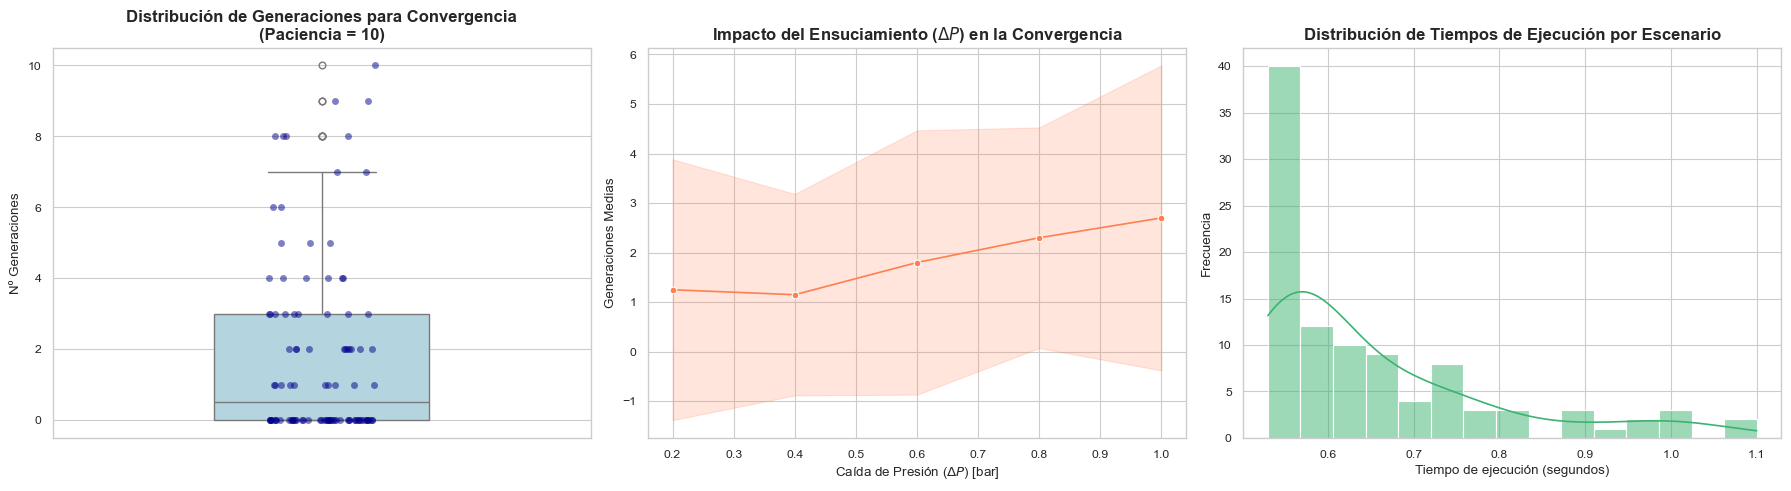


📊 RESUMEN ESTADÍSTICO PARA JUSTIFICACIÓN TÉCNICA (AUDITORÍA DATAGIA)
 - Escenarios evaluados:        100
 - Media de generaciones:       1.8
 - Mediana de generaciones:     0
 - Percentil 95 (P95):          8 generaciones
 - Percentil 99 (P99):          9 generaciones
 - Tiempo medio por escenario:  0.653 segundos
 - Tiempo max. detectado:       1.100 segundos
💡 RECOMENDACIÓN DE ARQUITECTURA PARA PRODUCCIÓN:
Basado en el muestreo estocástico sobre las variables no controlables, se ha
demostrado que el límite de saturación evolutiva ocurre, en el 95% de los casos,
antes de la generación 8. 

Fijar el hiperparámetro 'n_gen' = 13 (margen de seguridad) garantiza una 
solución óptima ahorrando un porcentaje sustancial de cálculo, siendo 
capaz de devolver un nuevo setpoint óptimo en ~0.65s, viable para IIoT.


In [8]:
# ==============================================================================
# CELDA 2: VISUALIZACIÓN Y ANÁLISIS ESTADÍSTICO DE LA CONVERGENCIA
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual profesional
sns.set_theme(style="whitegrid", context="paper")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Boxplot: Distribución de las generaciones necesarias para converger
sns.boxplot(y=df_convergencia['generaciones_convergencia'], ax=axes[0], color='lightblue', width=0.4)
sns.stripplot(y=df_convergencia['generaciones_convergencia'], ax=axes[0], color='darkblue', alpha=0.5, jitter=True)
axes[0].set_title('Distribución de Generaciones para Convergencia\n(Paciencia = 10)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nº Generaciones')

# 2. Lineplot: Relación entre Ensuciamiento (Fouling) y Convergencia
# ¿Cuesta más converger cuando la máquina está más sucia?
sns.lineplot(data=df_convergencia, x='Delta_P', y='generaciones_convergencia', 
             marker='o', errorbar='sd', ax=axes[1], color='coral')
axes[1].set_title('Impacto del Ensuciamiento ($\Delta P$) en la Convergencia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Caída de Presión ($\Delta P$) [bar]')
axes[1].set_ylabel('Generaciones Medias')

# 3. Histplot: Distribución de Tiempos de Ejecución
sns.histplot(df_convergencia['tiempo_ejecucion_s'], kde=True, ax=axes[2], color='mediumseagreen', bins=15)
axes[2].set_title('Distribución de Tiempos de Ejecución por Escenario', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tiempo de ejecución (segundos)')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../../models/artifacts/analisis_convergencia_ga.png', dpi=300)
plt.show()

# ==============================================================================
# REPORTE DE CONCLUSIONES PARA AUDITORÍA
# ==============================================================================
p95_gen = int(df_convergencia['generaciones_convergencia'].quantile(0.95))
p99_gen = int(df_convergencia['generaciones_convergencia'].quantile(0.99))
mean_time = df_convergencia['tiempo_ejecucion_s'].mean()

print("\n" + "="*70)
print("📊 RESUMEN ESTADÍSTICO PARA JUSTIFICACIÓN TÉCNICA (AUDITORÍA DATAGIA)")
print("="*70)
print(f" - Escenarios evaluados:        {len(df_convergencia)}")
print(f" - Media de generaciones:       {df_convergencia['generaciones_convergencia'].mean():.1f}")
print(f" - Mediana de generaciones:     {df_convergencia['generaciones_convergencia'].median():.0f}")
print(f" - Percentil 95 (P95):          {p95_gen} generaciones")
print(f" - Percentil 99 (P99):          {p99_gen} generaciones")
print(f" - Tiempo medio por escenario:  {mean_time:.3f} segundos")
print(f" - Tiempo max. detectado:       {df_convergencia['tiempo_ejecucion_s'].max():.3f} segundos")
print("="*70)
print(f"💡 RECOMENDACIÓN DE ARQUITECTURA PARA PRODUCCIÓN:")
print(f"Basado en el muestreo estocástico sobre las variables no controlables, se ha")
print(f"demostrado que el límite de saturación evolutiva ocurre, en el 95% de los casos,")
print(f"antes de la generación {p95_gen}. ")
print(f"\nFijar el hiperparámetro 'n_gen' = {p95_gen + 5} (margen de seguridad) garantiza una ")
print(f"solución óptima ahorrando un porcentaje sustancial de cálculo, siendo ")
print(f"capaz de devolver un nuevo setpoint óptimo en ~{mean_time:.2f}s, viable para IIoT.")

Aunque según la regla antes definida de fijarlo en +5 generaciones vamos a ser mas generosos y vamos a fijarlo en 15 generaciones para garantizar la convergencia
